In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [2]:
from arcgis.gis import GIS
from arcgis.features.find_locations import choose_best_facilities

gis = GIS("https://geosaurus.maps.arcgis.com", "arcgis_python", "amazing_arcgis_123")

In [26]:
office_item = gis.content.get('1f163950afbb4bf39f3ee67cf411761d')
esri_offices = office_item.layers[0]

In [29]:
hq_item = gis.content.get('c7665d3c8e6f48a79f07b79677996bed')
esri_hq = hq_item.layers[0]

In [5]:
clinic_item = gis.content.get('c69a634ae12249e08a9dc8d387bf5115')
clinic_lyr = clinic_item.layers[0]

In [6]:
gliderport_item = gis.content.get('5d93352406744d658d9c1f43f12b560c')
gliderport_lyr = gliderport_item.layers[0]

In [7]:
balloonport_item = gis.content.get('5d93352406744d658d9c1f43f12b560c')
balloonport_lyr = balloonport_item.layers[0]

<Item title:"USA Airports" type:Feature Layer Collection owner:esri_dm>
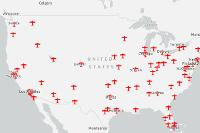

In [35]:
balloonport_item

In [8]:
facility1 = choose_best_facilities(demand_locations_layer=esri_offices,
                                   max_travel_range=30,
                                   travel_mode='Driving Time',
                                   required_facilities_layer=esri_hq, future=True)

In [9]:
facility1

<ChooseBestFacilities GP Job: jadc4216586624cc2bbc238ce0a15222b>

In [10]:
result = facility1.result()
result

{'allocated_demand_locations_layer': <FeatureCollection>,
 'allocation_lines_layer': <FeatureCollection>,
 'assigned_facilities_layer': <FeatureCollection>}

In [11]:
assert isinstance(result, dict)

In [12]:
from datetime import datetime
facility2 = choose_best_facilities(demand_locations_layer=esri_offices,
                                   max_travel_range=30,
                                   travel_mode='Driving Time',
                                   required_facilities_layer=esri_hq,
                                   output_name="facilitiestest" + str(datetime.now().microsecond))
facility2job = choose_best_facilities(demand_locations_layer=esri_offices,
                                   max_travel_range=30,
                                   travel_mode='Driving Time',
                                   required_facilities_layer=esri_hq, future=True,
                                   output_name="facilitiestest" + str(datetime.now().microsecond))

In [13]:
assert isinstance(facility2, Item)
facility2

<Item title:"facilitiestest781879" type:Feature Layer Collection owner:arcgis_python>

In [18]:
facility2.delete()

True

In [19]:
assert isinstance(facility2job, GPJob)
assert isinstance(facility2job.result(), Item)
assert facility2job.result().delete()

#### Test Overwrite

In [20]:
import sys
sys.path.insert(0, r"C:\\ipython_workfolder\\geosaurus\\src")
from arcgis.gis import GIS
portal = GIS(profile="your_portal_profile", verify_cert=False) #need to be at least enetrprise 10.9.1

In [36]:
clinic_item = portal.content.get('7a1ecc59e0a443d485dfd123b7a293ef')
clinic_layer = clinic_item.layers[0]

In [37]:
airport_item = portal.content.get('8c3a85d4032049ff8333965c6a2a6219')
heliport_layer = airport_item.layers[4]
airport_layer = airport_item.layers[1]

In [47]:
facility3 = choose_best_facilities(demand_locations_layer=airport_layer,
                                   max_travel_range=30,
                                   travel_mode='Driving Time',
                                   required_facilities_layer=clinic_layer,
                                   output_name="facilitiestest")

In [48]:
fl_to_overwrite = portal.content.get(facility3.id).layers[0]
fl_to_overwrite

<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/0">

In [49]:
facility_overwrite = choose_best_facilities(demand_locations_layer=airport_layer,
                                   max_travel_range=30,
                                   travel_mode='Driving Time',
                                   required_facilities_layer=clinic_layer,
                                   output_name=fl_to_overwrite,
                                   context={"overwrite": True})

In [53]:
print(facility_overwrite.id)
print(facility_overwrite.layers)

'a48efe17148e4bada3c3ee2cef7ccbc5'

In [57]:
print(facility3.id)
for layer in facility3.layers:
    print(layer)

a48efe17148e4bada3c3ee2cef7ccbc5
<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/0">
<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/1">
<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/2">
<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/3">
<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/4">
<FeatureLayer url:"https://gpportal.esri.com/server/rest/services/Hosted/facilitiestest/FeatureServer/5">


In [58]:
facility3.delete()

True